# Root inspector

Inspect .root files and its branches and leaves and such. Create plots that visualize the experiement shows hits in ECal in 2D and 3D plots. Inspects ancestry labels that are stored in branches. 

Hans Alin gjorde fina plots i 2D plots ECal RecHits och de var inspiration till detta. 

**Tips!** Om man vill navigera sig i events.root-filer med ROOT-programmet (tips från Lene-Kristian)

denv rootbrowse runs/it_pileup/events.root

## Importera och välj typ av events-fil (output från it_pileup/xxx.py)

Alternativ: 

ecal_pn.root

pileup.root

events.root


Inspektera filen och se vilka unika branches, leaves osv som finns i uproot trädet och utgå från det i resten av denna fil som inspekterar .root filer.

In [4]:
print("hello")

hello


In [ ]:
import uproot
import matplotlib.pyplot as plt
import awkward as ak

#events_path = "../../runs/it_pileup/events.root"
#events_path = "../../runs/overlay_main10000_pileup20000_00/events.root"
#events_path = "../../runs/overlay_from_hans_cosmos_00/events.root"
events_path = "../data/ldmx_overlay_events_700k/3e/events/events_1.root"

figures_path = "figures/"

file = uproot.open(events_path)
tree = file["LDMX_Events"]
tree_keys = set(tree.keys())

overlay_tree = "EcalRecHits_overlay/EcalRecHits_overlay.energy_" in tree_keys
pileup_tree = "EcalSimHits_pileup/EcalSimHits_pileup.edep_" in tree_keys
ecal_pn_tree = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.edep_" in tree_keys

if overlay_tree:
    ecal_hit_label = "RecHits"
    ecal_x_branch = "EcalRecHits_overlay/EcalRecHits_overlay.xpos_"
    ecal_y_branch = "EcalRecHits_overlay/EcalRecHits_overlay.ypos_"
    ecal_z_branch = "EcalRecHits_overlay/EcalRecHits_overlay.zpos_"
    ecal_energy_branch = "EcalRecHits_overlay/EcalRecHits_overlay.energy_"
elif pileup_tree:
    ecal_hit_label = "SimHits"
    ecal_x_branch = "EcalSimHits_pileup/EcalSimHits_pileup.x_"
    ecal_y_branch = "EcalSimHits_pileup/EcalSimHits_pileup.y_"
    ecal_z_branch = "EcalSimHits_pileup/EcalSimHits_pileup.z_"
    ecal_energy_branch = "EcalSimHits_pileup/EcalSimHits_pileup.edep_"
elif ecal_pn_tree:
    ecal_hit_label = "SimHits"
    ecal_x_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.x_"
    ecal_y_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.y_"
    ecal_z_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.z_"
    ecal_energy_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.edep_"
else:
    raise KeyError("Could not find a supported ECal branch layout in this ROOT file.")

keys = [k.split(";")[0] for k in file.keys()]          # strip ROOT cycle suffix ";1"
keys = sorted(set(keys))

print(f"Found {len(keys)} unique objects in {events_path}\n")
for k in keys:
    print(k)

print("\nBRANCHES:")
for b in tree.keys():
    print(b)

#print(f"\nDetected ECal layout: {ecal_hit_label}")

Found 2 unique objects in ../ml_ldmx/data/ldmx_overlay_events_700k/3e/events/events_1.root

LDMX_Events
LDMX_Run

BRANCHES:
SimParticles_test
SimParticles_test/SimParticles_test.first
SimParticles_test/SimParticles_test.second.energy_
SimParticles_test/SimParticles_test.second.pdg_id_
SimParticles_test/SimParticles_test.second.gen_status_
SimParticles_test/SimParticles_test.second.time_
SimParticles_test/SimParticles_test.second.vtx_x_
SimParticles_test/SimParticles_test.second.vtx_y_
SimParticles_test/SimParticles_test.second.vtx_z_
SimParticles_test/SimParticles_test.second.end_x_
SimParticles_test/SimParticles_test.second.end_y_
SimParticles_test/SimParticles_test.second.end_z_
SimParticles_test/SimParticles_test.second.px_
SimParticles_test/SimParticles_test.second.py_
SimParticles_test/SimParticles_test.second.pz_
SimParticles_test/SimParticles_test.second.end_px_
SimParticles_test/SimParticles_test.second.end_py_
SimParticles_test/SimParticles_test.second.end_pz_
SimParticles_tes

In [6]:
with uproot.open(events_path) as f:
    print("Top-level keys:")
    print(f.keys())

    # Pick the main tree.
    # Often in LDMX files this may be called "LDMX_Events"
    tree = f["LDMX_Events"]

    print("Number of events:", tree.num_entries)

Top-level keys:
['LDMX_Events;2', 'LDMX_Events;1', 'LDMX_Run;1']
Number of events: 5000


## Inspect TriggerPadTracks centroid and PE data

This cell inspects the trigger scintillator tracker track branches (`centroid_` and `pe_`) numerically for the first 9 events, then plots the jagged per-event content as heatmaps. The `centroid_` values are also compared to `centroid_x_`, `centroid_y_`, and `centroid_z_` so it is clear which coordinate carries the useful one-dimensional tracker information.

TERMINAL OUTPUT 1: TriggerPadTracks branch shapes
Selected collection: TriggerPadTracks_overlay
Events in file: 5000
Events inspected here: 9
Tracks per inspected event: [2, 1, 3, 2, 3, 2, 2, 3, 3]

  centroid: TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_
            type = 9 * var * float32
            first-event values = [16.69487953186035, 26.666322708129883]
centroid_x: TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_x_
            type = 9 * var * float32
            first-event values = [-1.0, -1.0]
centroid_y: TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_y_
            type = 9 * var * float32
            first-event values = [16.69487953186035, 26.666322708129883]
centroid_z: TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_z_
            type = 9 * var * float32
            first-event values = [-99999.0, -99999.0]
        pe: TriggerPadTracks_overlay/TriggerPadTracks_overlay.pe_
            type = 9 * var * float32
          

,event,track_in_event,centroid,centroid_x,centroid_y,centroid_z,pe,n_clusters,beam_efrac
0,0,0,16.694880,-1.0,16.694880,-99999.0,301.666656,0,1.000000
1,0,1,26.666323,-1.0,26.666323,-99999.0,138.000000,0,1.000000
2,1,0,24.695349,-1.0,24.695349,-99999.0,268.333344,0,0.927509
3,2,0,4.447050,-1.0,4.447050,-99999.0,185.666672,0,1.000000
4,2,1,26.513998,-1.0,26.513998,-99999.0,173.000000,0,1.000000
5,2,2,45.240967,-1.0,45.240967,-99999.0,232.333328,0,0.748158
6,3,0,33.433781,-1.0,33.433781,-99999.0,388.000000,0,1.000000
7,3,1,39.800926,-1.0,39.800926,-99999.0,125.000000,0,1.000000
8,4,0,0.468546,-1.0,0.468546,-99999.0,210.000000,0,0.931623
9,4,1,26.539108,-1.0,26.539108,-99999.0,146.666672,0,1.000000



Numerical summary for inspected trigger-pad tracks:


,centroid,centroid_x,centroid_y,centroid_z,pe,n_clusters,beam_efrac
count,21.000000,21.0,21.000000,21.0,21.000000,21.0,21.000000
mean,25.567332,-1.0,25.567332,-99999.0,199.333333,0.0,0.953044
std,14.006374,0.0,14.006374,0.0,62.814452,0.0,0.074689
min,0.468546,-1.0,0.468546,-99999.0,102.333336,0.0,0.748158
25%,16.694880,-1.0,16.694880,-99999.0,173.000000,0.0,0.931623
50%,26.513998,-1.0,26.513998,-99999.0,187.333328,0.0,1.000000
75%,38.549450,-1.0,38.549450,-99999.0,212.333328,0.0,1.000000
max,45.240967,-1.0,45.240967,-99999.0,388.000000,0.0,1.000000


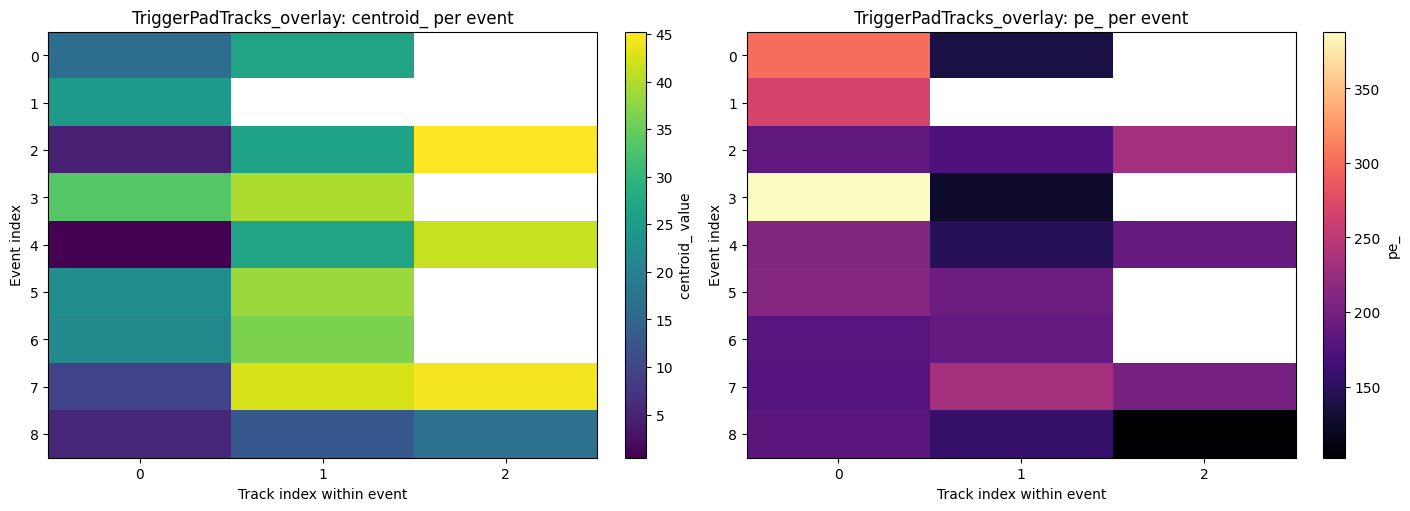

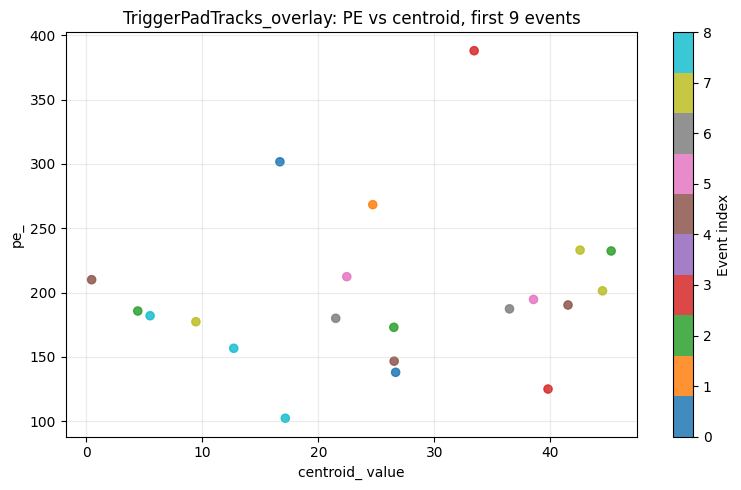

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak

# Pick the trigger-pad track collection available in this ROOT file.
# You can change the order below if you specifically want X or Y tracks.
trigger_track_candidates = [
    "TriggerPadTracks_overlay",
    "TriggerPadTracksY_overlay",
    "TriggerPadTracksX_overlay",
]

trigger_track_collection = None
for candidate in trigger_track_candidates:
    centroid_branch = f"{candidate}/{candidate}.centroid_"
    pe_branch = f"{candidate}/{candidate}.pe_"
    if centroid_branch in tree_keys and pe_branch in tree_keys:
        trigger_track_collection = candidate
        break

if trigger_track_collection is None:
    raise KeyError("Could not find TriggerPadTracks centroid_ and pe_ branches in this ROOT file.")

trigger_branches = {
    "centroid": f"{trigger_track_collection}/{trigger_track_collection}.centroid_",
    "centroid_x": f"{trigger_track_collection}/{trigger_track_collection}.centroid_x_",
    "centroid_y": f"{trigger_track_collection}/{trigger_track_collection}.centroid_y_",
    "centroid_z": f"{trigger_track_collection}/{trigger_track_collection}.centroid_z_",
    "pe": f"{trigger_track_collection}/{trigger_track_collection}.pe_",
    "n_clusters": f"{trigger_track_collection}/{trigger_track_collection}.n_clusters_",
    "beam_efrac": f"{trigger_track_collection}/{trigger_track_collection}.beam_efrac_",
}

n_events_to_show = min(9, tree.num_entries)
trigger_arrays = tree.arrays(list(trigger_branches.values()), entry_stop=n_events_to_show, library="ak")

centroid = trigger_arrays[trigger_branches["centroid"]]
centroid_x = trigger_arrays[trigger_branches["centroid_x"]]
centroid_y = trigger_arrays[trigger_branches["centroid_y"]]
centroid_z = trigger_arrays[trigger_branches["centroid_z"]]
pe = trigger_arrays[trigger_branches["pe"]]
n_clusters = trigger_arrays[trigger_branches["n_clusters"]]
beam_efrac = trigger_arrays[trigger_branches["beam_efrac"]]
track_counts = ak.num(centroid, axis=1)
max_tracks = int(ak.max(track_counts)) if len(track_counts) else 0

def jagged_to_padded_numpy(array, width):
    """Convert first events of a jagged Awkward array to a rectangular array for heatmaps."""
    if width == 0:
        return np.empty((len(array), 0))
    return ak.to_numpy(ak.fill_none(ak.pad_none(array, width, axis=1, clip=True), np.nan))

centroid_grid = jagged_to_padded_numpy(centroid, max_tracks)
pe_grid = jagged_to_padded_numpy(pe, max_tracks)

print("TERMINAL OUTPUT 1: TriggerPadTracks branch shapes")
print(f"Selected collection: {trigger_track_collection}")
print(f"Events in file: {tree.num_entries}")
print(f"Events inspected here: {n_events_to_show}")
print(f"Tracks per inspected event: {ak.to_list(track_counts)}")
print()
for label, branch in trigger_branches.items():
    arr = trigger_arrays[branch]
    print(f"{label:>10}: {branch}")
    print(f"            type = {ak.type(arr)}")
    print(f"            first-event values = {ak.to_list(arr[0]) if len(arr) else []}")

rows = []
for event_idx in range(n_events_to_show):
    for track_idx in range(int(track_counts[event_idx])):
        rows.append({
            "event": event_idx,
            "track_in_event": track_idx,
            "centroid": float(centroid[event_idx][track_idx]),
            "centroid_x": float(centroid_x[event_idx][track_idx]),
            "centroid_y": float(centroid_y[event_idx][track_idx]),
            "centroid_z": float(centroid_z[event_idx][track_idx]),
            "pe": float(pe[event_idx][track_idx]),
            "n_clusters": int(n_clusters[event_idx][track_idx]),
            "beam_efrac": float(beam_efrac[event_idx][track_idx]),
        })

trigger_track_df = pd.DataFrame(rows)

print("\nTERMINAL OUTPUT 2: First 9 events, one row per trigger-pad track")
if trigger_track_df.empty:
    print("No trigger-pad tracks found in the inspected events.")
else:
    display(trigger_track_df)
    print("\nNumerical summary for inspected trigger-pad tracks:")
    display(trigger_track_df[["centroid", "centroid_x", "centroid_y", "centroid_z", "pe", "n_clusters", "beam_efrac"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

centroid_image = axes[0].imshow(centroid_grid, aspect="auto", interpolation="nearest", cmap="viridis")
axes[0].set_title(f"{trigger_track_collection}: centroid_ per event")
axes[0].set_xlabel("Track index within event")
axes[0].set_ylabel("Event index")
axes[0].set_xticks(range(max_tracks))
axes[0].set_yticks(range(n_events_to_show))
fig.colorbar(centroid_image, ax=axes[0], label="centroid_ value")

pe_image = axes[1].imshow(pe_grid, aspect="auto", interpolation="nearest", cmap="magma")
axes[1].set_title(f"{trigger_track_collection}: pe_ per event")
axes[1].set_xlabel("Track index within event")
axes[1].set_ylabel("Event index")
axes[1].set_xticks(range(max_tracks))
axes[1].set_yticks(range(n_events_to_show))
fig.colorbar(pe_image, ax=axes[1], label="pe_")

plt.savefig(f"{figures_path}trigger_pad_tracks_centroid_pe_heatmaps.png", dpi=300)
plt.show()

if not trigger_track_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    scatter = ax.scatter(
        trigger_track_df["centroid"],
        trigger_track_df["pe"],
        c=trigger_track_df["event"],
        s=35 + 12 * trigger_track_df["n_clusters"],
        alpha=0.85,
        cmap="tab10",
    )
    ax.set_title(f"{trigger_track_collection}: PE vs centroid, first {n_events_to_show} events")
    ax.set_xlabel("centroid_ value")
    ax.set_ylabel("pe_")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Event index")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{figures_path}trigger_pad_tracks_pe_vs_centroid.png", dpi=300)
    plt.show()


## Inspect ECal hit metadata and output a table

Here one can inspect track_id and origin_id for specific hits. origin_id encodes ancestry information and is found in the contrib branch.

In [8]:
# Find all events with ECal RecHits marked as noise.
import awkward as ak
import pandas as pd

noise_flag_branch = "EcalRecHits_overlay/EcalRecHits_overlay.is_noise_"
noise_id_branch = "EcalRecHits_overlay/EcalRecHits_overlay.id_"
noise_energy_branch = "EcalRecHits_overlay/EcalRecHits_overlay.energy_"

if not overlay_tree or not all(branch in tree_keys for branch in [noise_flag_branch, noise_id_branch, noise_energy_branch]):
    print("No EcalRecHits_overlay noise flag is available for this file.")
    noise_events_df = pd.DataFrame()
else:
    noise_arrs = tree.arrays([noise_flag_branch, noise_id_branch, noise_energy_branch])
    noise_event_rows = []

    for iev in range(len(noise_arrs[noise_flag_branch])):
        flags = ak.to_list(noise_arrs[noise_flag_branch][iev])
        ids_for_event = ak.to_list(noise_arrs[noise_id_branch][iev])
        energies_for_event = ak.to_list(noise_arrs[noise_energy_branch][iev])
        noisy_hits = [
            (int(hit_id), float(energy))
            for hit_id, energy, flag in zip(ids_for_event, energies_for_event, flags)
            if bool(flag)
        ]

        if noisy_hits:
            noise_event_rows.append({
                "event_idx": iev,
                "n_noise_hits": len(noisy_hits),
                "noise_hit_ids": [hit_id for hit_id, _ in noisy_hits],
                "noise_hit_energies": [energy for _, energy in noisy_hits],
            })

    noise_events_df = pd.DataFrame(noise_event_rows)
    total_events = len(noise_arrs[noise_flag_branch])
    total_noise_events = len(noise_events_df)
    noise_events_summary_df = pd.DataFrame([{
        "total_events": total_events,
        "total_events_with_noise": total_noise_events,
    }])
    print(f"Found {total_noise_events} events with ECal noise hits.")
    display(noise_events_summary_df)
    display(noise_events_df)

    # Extract the event indices with noise hits
    #event_idx_with_noise = noise_events_df['event_idx'].tolist()
    #print(f"Event indices with noise hits: {event_idx_with_noise}")

Found 142 events with ECal noise hits.


,total_events,total_events_with_noise
0,5000,142


,event_idx,n_noise_hits,noise_hit_ids,noise_hit_energies
0,3,1,[337654063],[3.239717483520508]
1,21,1,[335823183],[1.9809297323226929]
2,52,1,[339349883],[5.463949680328369]
3,54,1,[337924375],[3.8876609802246094]
4,67,1,[337248291],[3.239717483520508]
...,...,...,...,...
137,4889,1,[336093220],[2.2863519191741943]
138,4919,1,[335552820],[0.6463904976844788]
139,4963,1,[336216222],[2.921928882598877]
140,4966,1,[336093580],[2.2863519191741943]


In [9]:
import awkward as ak
import numpy as np
import pandas as pd

event_idx = 9

# Three different cases...
if overlay_tree and "EcalSimHitsOverlay_overlay/EcalSimHitsOverlay_overlay.id_" in tree_keys:
    simhit_prefix = "EcalSimHitsOverlay_overlay/EcalSimHitsOverlay_overlay"
elif "EcalSimHits_pileup/EcalSimHits_pileup.id_" in tree_keys:
    simhit_prefix = "EcalSimHits_pileup/EcalSimHits_pileup"
elif "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.id_" in tree_keys:
    simhit_prefix = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn"
else:
    raise KeyError("Could not find a supported ECal sim-hit collection in this ROOT file.")

# These are named the same in all three cases
branches = [
    f"{simhit_prefix}.id_",
    f"{simhit_prefix}.edep_",
    f"{simhit_prefix}.x_",
    f"{simhit_prefix}.y_",
    f"{simhit_prefix}.z_",
]

optional_suffixes = [
    "n_contribs_",
    "track_id_contribs_",
    "origin_contribs_",
    "edep_contribs_",
    "pdg_code_contribs_",
]
for suffix in optional_suffixes:
    branch_name = f"{simhit_prefix}.{suffix}"
    if branch_name in tree_keys:
        branches.append(branch_name)

arrs = tree.arrays(branches)

ids  = arrs[f"{simhit_prefix}.id_"][event_idx]
edep = arrs[f"{simhit_prefix}.edep_"][event_idx]
x    = arrs[f"{simhit_prefix}.x_"][event_idx]
y    = arrs[f"{simhit_prefix}.y_"][event_idx]
z    = arrs[f"{simhit_prefix}.z_"][event_idx]

rec_id_branch = "EcalRecHits_overlay/EcalRecHits_overlay.id_"
rec_energy_branch = "EcalRecHits_overlay/EcalRecHits_overlay.energy_"
rec_x_branch = "EcalRecHits_overlay/EcalRecHits_overlay.xpos_"
rec_y_branch = "EcalRecHits_overlay/EcalRecHits_overlay.ypos_"
rec_z_branch = "EcalRecHits_overlay/EcalRecHits_overlay.zpos_"
rec_noise_branch = "EcalRecHits_overlay/EcalRecHits_overlay.is_noise_"
rec_branches = [rec_id_branch, rec_energy_branch, rec_x_branch, rec_y_branch, rec_z_branch, rec_noise_branch]
rec_noise_by_hit_id = {}
rec_hit_by_id = {}
if overlay_tree and all(branch in tree_keys for branch in rec_branches):
    rec_arrs = tree.arrays(rec_branches)
    rec_ids = rec_arrs[rec_id_branch][event_idx]
    rec_energy = rec_arrs[rec_energy_branch][event_idx]
    rec_x = rec_arrs[rec_x_branch][event_idx]
    rec_y = rec_arrs[rec_y_branch][event_idx]
    rec_z = rec_arrs[rec_z_branch][event_idx]
    rec_is_noise = rec_arrs[rec_noise_branch][event_idx]
    for hit_id, energy, rx, ry, rz, is_noise in zip(
        ak.to_list(rec_ids),
        ak.to_list(rec_energy),
        ak.to_list(rec_x),
        ak.to_list(rec_y),
        ak.to_list(rec_z),
        ak.to_list(rec_is_noise),
    ):
        hit_id = int(hit_id)
        rec_noise_by_hit_id[hit_id] = bool(is_noise)
        rec_hit_by_id[hit_id] = {
            "hit_id": hit_id,
            "x": float(rx),
            "y": float(ry),
            "z": float(rz),
            "hit_edep": float(energy),
            "is_noise": bool(is_noise),
        }

def ecal_is_noise(hit_id):
    return bool(rec_noise_by_hit_id.get(int(hit_id), False))

has_contrib_info = f"{simhit_prefix}.n_contribs_" in arrs.fields
if has_contrib_info:
    ncontrib  = arrs[f"{simhit_prefix}.n_contribs_"][event_idx]
    track_ids = arrs[f"{simhit_prefix}.track_id_contribs_"][event_idx]
    origins   = arrs[f"{simhit_prefix}.origin_contribs_"][event_idx]
    edep_c    = arrs[f"{simhit_prefix}.edep_contribs_"][event_idx]
    pdg_c     = arrs[f"{simhit_prefix}.pdg_code_contribs_"][event_idx]

rows = []
for ihit in range(len(ids)):
    if has_contrib_info:
        n = int(ncontrib[ihit])
        if n == 0:
            rows.append({
                "hit_idx": ihit,
                "hit_id": int(ids[ihit]),
                "x": float(x[ihit]),
                "y": float(y[ihit]),
                "z": float(z[ihit]),
                "hit_edep": float(edep[ihit]),
                "is_noise": ecal_is_noise(ids[ihit]),
                "n_contribs": 0,
                "dominant_track_id": -1,
                "dominant_origin": -1,
                "dominant_pdg": 0,
                "dominant_frac": np.nan,
                "is_mixed": False,
                "all_track_ids": [],
                "all_origins": [],
            })
            continue

        hit_track_ids = [int(v) for v in ak.to_list(track_ids[ihit])]
        hit_origins   = [int(v) for v in ak.to_list(origins[ihit])]
        hit_edep_c    = [float(v) for v in ak.to_list(edep_c[ihit])]
        hit_pdg_c     = [int(v) for v in ak.to_list(pdg_c[ihit])]

        dom = int(np.argmax(hit_edep_c))
        total_c = sum(hit_edep_c)
        distinct_tracks = set(hit_track_ids)

        rows.append({
            "hit_idx": ihit,
            "hit_id": int(ids[ihit]),
            "x": float(x[ihit]),
            "y": float(y[ihit]),
            "z": float(z[ihit]),
            "hit_edep": float(edep[ihit]),
            "is_noise": ecal_is_noise(ids[ihit]),
            "n_contribs": n,
            "dominant_track_id": hit_track_ids[dom],
            "dominant_origin": hit_origins[dom],
            "dominant_pdg": hit_pdg_c[dom],
            "dominant_frac": hit_edep_c[dom] / total_c if total_c > 0 else np.nan,
            "is_mixed": len(distinct_tracks) > 1, # BAD
            "all_track_ids": hit_track_ids,
            "all_origins": hit_origins,
        })
    else:
        rows.append({
            "hit_idx": ihit,
            "hit_id": int(ids[ihit]),
            "x": float(x[ihit]),
            "y": float(y[ihit]),
            "z": float(z[ihit]),
            "hit_edep": float(edep[ihit]),
            "is_noise": ecal_is_noise(ids[ihit]),
            "n_contribs": 1,
            "dominant_track_id": -1,
            "dominant_origin": -1,
            "dominant_pdg": 0,
            "dominant_frac": np.nan,
            "is_mixed": False,
            "all_track_ids": [],
            "all_origins": [],
        })

existing_hit_ids = {row["hit_id"] for row in rows}
for rec_hit in rec_hit_by_id.values():
    if rec_hit["is_noise"] and rec_hit["hit_id"] not in existing_hit_ids:
        rows.append({
            "hit_idx": len(rows),
            "hit_id": rec_hit["hit_id"],
            "x": rec_hit["x"],
            "y": rec_hit["y"],
            "z": rec_hit["z"],
            "hit_edep": rec_hit["hit_edep"],
            "is_noise": True,
            "n_contribs": 0,
            "dominant_track_id": -1,
            "dominant_origin": -1,
            "dominant_pdg": 0,
            "dominant_frac": np.nan,
            "is_mixed": False,
            "all_track_ids": [],
            "all_origins": [],
        })

hits_df = pd.DataFrame(rows)
hits_df.head(20)

,hit_idx,hit_id,x,y,z,hit_edep,is_noise,n_contribs,dominant_track_id,dominant_origin,dominant_pdg,dominant_frac,is_mixed,all_track_ids,all_origins
0,0,335544488,-13.594433,-36.072506,247.632004,0.123026,False,1,167772161,3,11,1.000000,False,[167772161],[3]
1,1,335544507,-10.791312,-7.437341,247.552399,0.234113,False,2,134219163,1,11,0.516967,True,"[134217729, 134219163]","[1, 1]"
2,2,335544510,-10.338792,-36.010750,247.632004,0.257074,False,1,167773887,3,11,1.000000,False,[167773887],[3]
3,3,335544525,-2.502692,36.843697,247.632004,0.166897,False,1,150994945,2,11,1.000000,False,[150994945],[2]
4,4,335544557,6.947064,-36.136227,247.632004,0.132644,False,1,167773888,3,-11,1.000000,False,[167773888],[3]
5,5,335548562,146.184158,-34.124821,247.632004,0.229611,False,1,167773774,3,-11,1.000000,False,[167773774],[3]
6,6,335561023,-139.323868,-19.232065,247.632004,0.245586,False,1,167773773,3,11,1.000000,False,[167773773],[3]
7,7,335675556,-10.849964,-7.417185,256.212006,0.250263,False,2,134219163,1,11,0.500839,True,"[134217729, 134219163]","[1, 1]"
8,8,335675560,-13.757597,-36.072666,256.212006,0.215300,False,2,167773887,3,11,0.528291,True,"[167772161, 167773887]","[3, 3]"
9,9,335675574,-2.569978,36.840801,256.179993,0.156306,False,1,150994945,2,11,1.000000,False,[150994945],[2]


### Ett exempel på hur en encoded track ID blir decoded

In [10]:
def decode_track_id(x):
    if x < 0:
        return None
    return {
        "raw": int(x),
        "version": (x >> 27) & 0xF,
        "event_index": (x >> 24) & 0x7,
        "track_id": x & ((1 << 24) - 1),
    }

print(decode_track_id(134217729))
print(decode_track_id(150994945))

# origin id
print(decode_track_id(134217729))          
print(decode_track_id(150994945))

{'raw': 134217729, 'version': 1, 'event_index': 0, 'track_id': 1}
{'raw': 150994945, 'version': 1, 'event_index': 1, 'track_id': 1}
{'raw': 134217729, 'version': 1, 'event_index': 0, 'track_id': 1}
{'raw': 150994945, 'version': 1, 'event_index': 1, 'track_id': 1}


Hitta EcalRecHits i x, y, z

Hitta energierna för de olika hits som finns och plotta i histogram

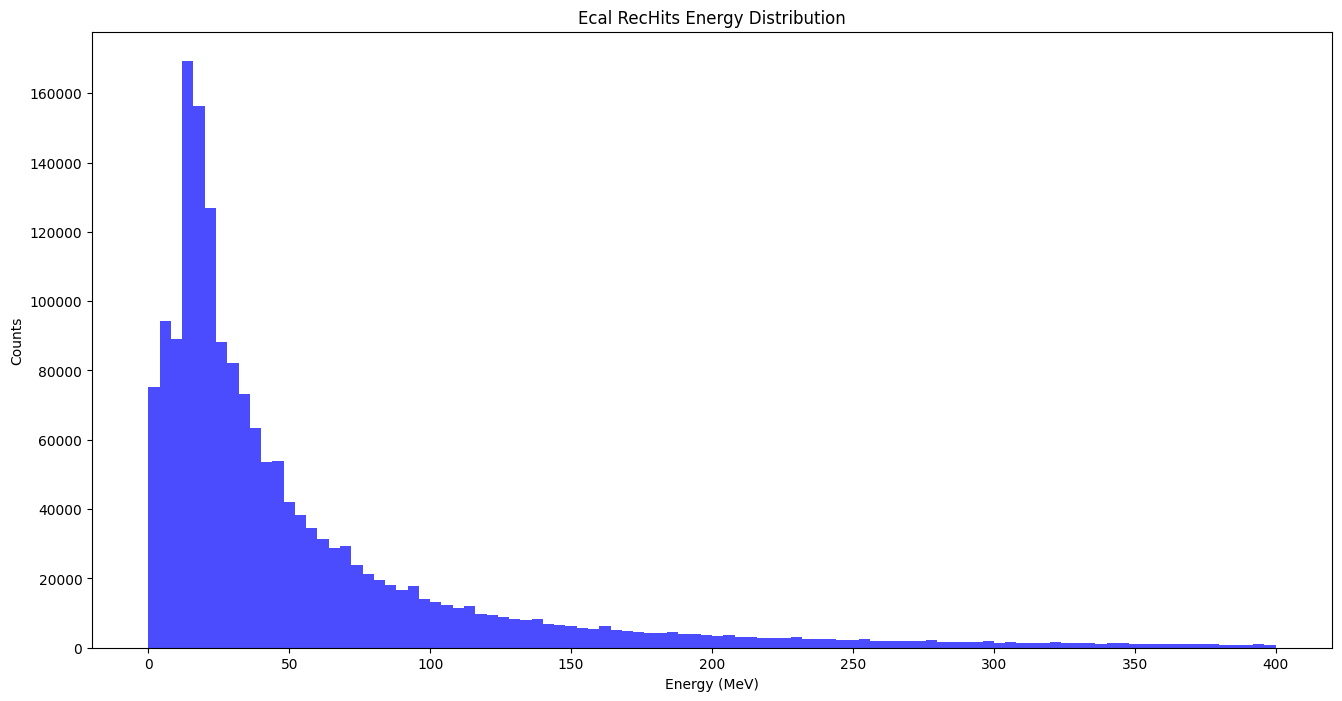

In [11]:
# To array x, y ,z and energy of the detected ECal hit collection
ecal_y = tree[ecal_y_branch].array()
ecal_x = tree[ecal_x_branch].array()
ecal_z = tree[ecal_z_branch].array()
ecal_energy = tree[ecal_energy_branch].array()

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.hist(ak.flatten(ecal_energy), bins=100, alpha=0.7, color='blue', range=[0,400])
ax.set_title(f"Ecal {ecal_hit_label} Energy Distribution")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Counts")
plt.savefig(f"{figures_path}ecal_energy.png", dpi=300)
#plt.close()

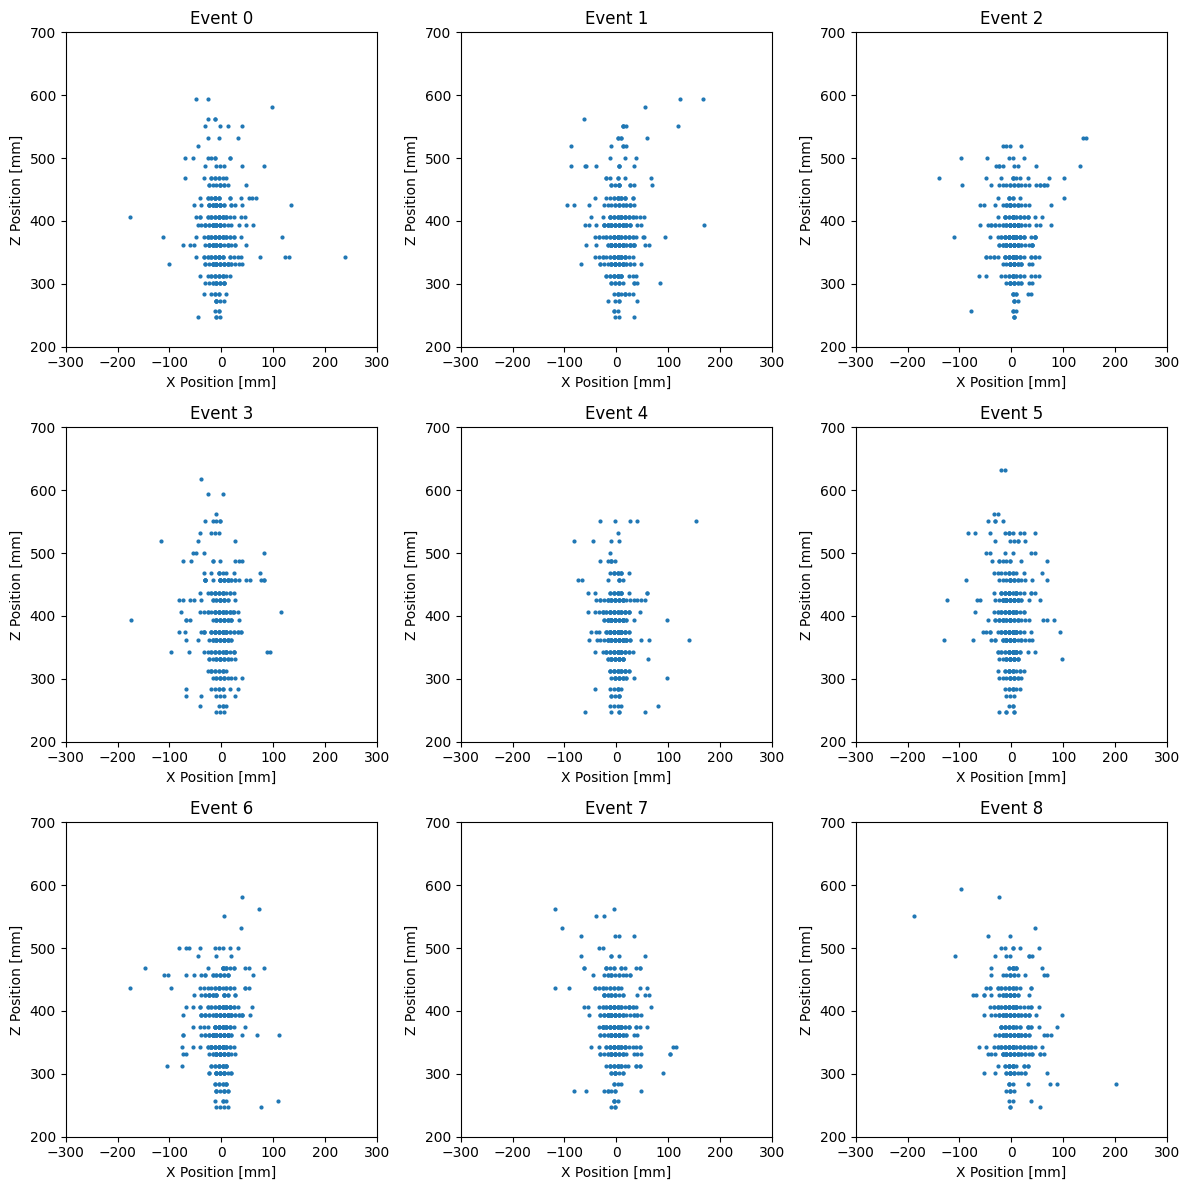

In [12]:
# Scatter plots of x vs z for up to first 9 events (3x3 grid)

rows, columns = 3, 3
nplots = rows * columns
nevents = len(ecal_x)
nshow = min(nplots, nevents)

fig, ax = plt.subplots(rows, columns, figsize=(12, 12))
ax = ax.flatten()

for index in range(nshow):
    ax[index].scatter(ecal_x[index], ecal_z[index], s=4)
    ax[index].set_title(f"Event {index}")
    ax[index].set_xlabel("X Position [mm]")
    ax[index].set_ylabel("Z Position [mm]")
    ax[index].set_xlim(-300, 300)
    ax[index].set_ylim(200, 700)

# turn off unused panels if fewer than 9 events
for index in range(nshow, nplots):
    ax[index].axis("off")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_x_z_hits_3x3.png", dpi=300)
plt.show()

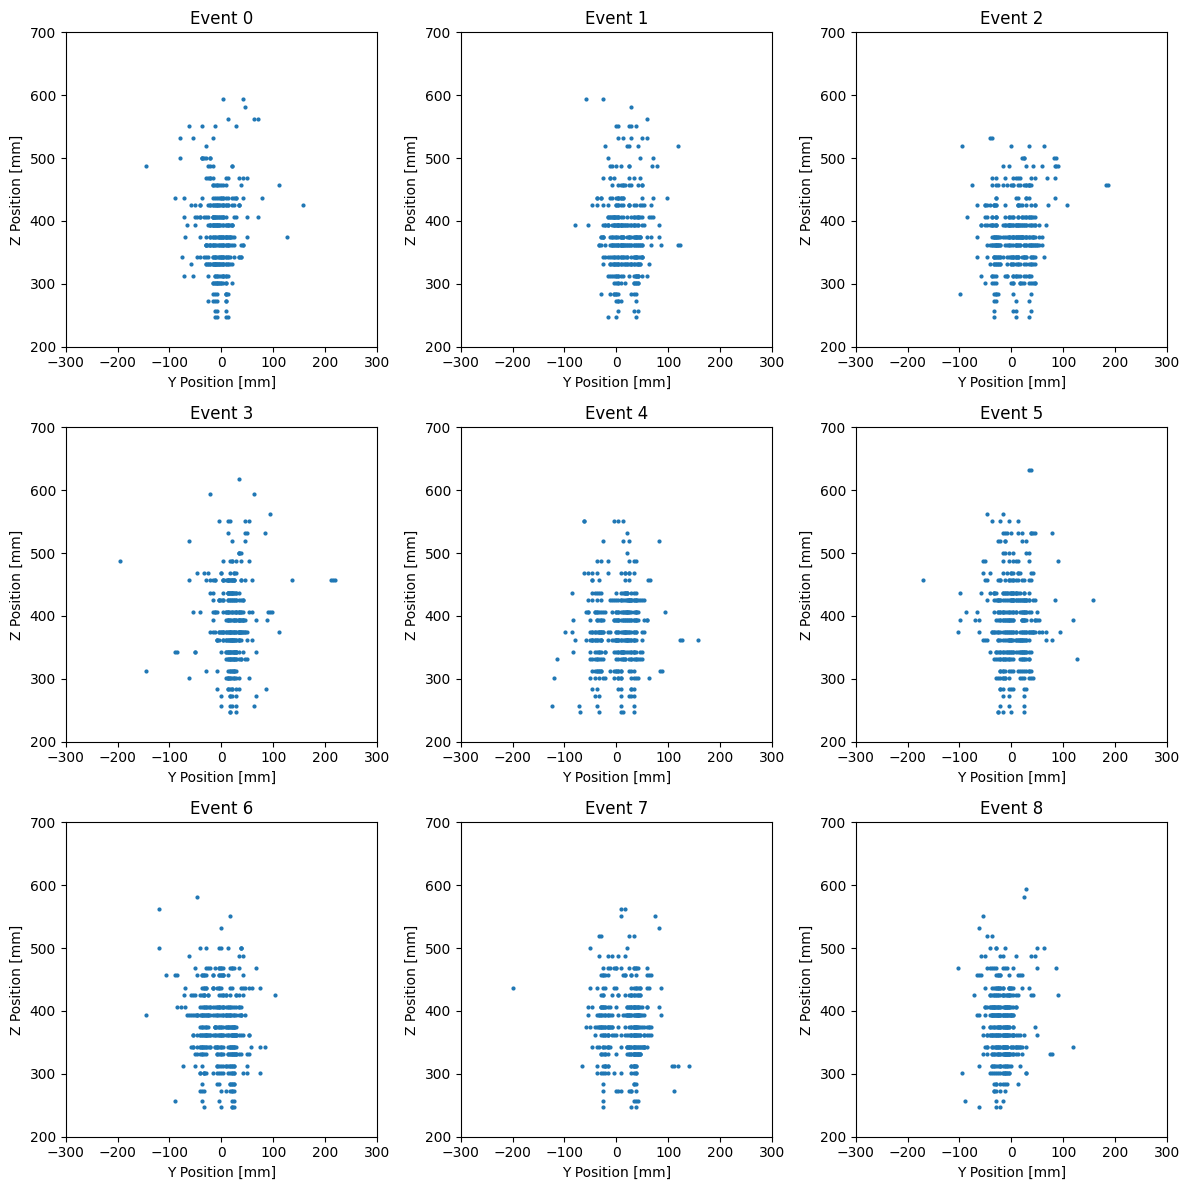

In [13]:
# Scatter plots of y vs z for up to first 9 events (3x3 grid)

rows, columns = 3, 3
nplots = rows * columns
nevents = len(ecal_y)
nshow = min(nplots, nevents)

fig, ax = plt.subplots(rows, columns, figsize=(12, 12))
ax = ax.flatten()

for index in range(nshow):
    ax[index].scatter(ecal_y[index], ecal_z[index], s=4)
    ax[index].set_title(f"Event {index}")
    ax[index].set_xlabel("Y Position [mm]")
    ax[index].set_ylabel("Z Position [mm]")
    ax[index].set_xlim(-300, 300)
    ax[index].set_ylim(200, 700)

# turn off unused panels
for index in range(nshow, nplots):
    ax[index].axis("off")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_y_z_hits_3x3.png", dpi=300)
plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_category_codes(series):
    cats = pd.Categorical(series)
    return cats.codes, list(cats.categories)

def plot_simhits_2d(
    df,
    event_idx=0,
    xcol="z",
    ycol="x",
    color_mode="hit_edep",
    annotate=False,
    max_labels=40,
    figsize=(10, 6),
):
    plot_df = df.copy()

    fig, ax = plt.subplots(figsize=figsize)

    if color_mode == "hit_edep":
        sizes = 10 + 120 * plot_df["hit_edep"] / plot_df["hit_edep"].max()
        sc = ax.scatter(
            plot_df[xcol],
            plot_df[ycol],
            c=plot_df["hit_edep"],
            s=sizes,
            alpha=0.8,
        )
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Hit energy [MeV]")

    elif color_mode in ["dominant_track_id", "dominant_origin", "dominant_pdg", "is_mixed"]:
        vals = plot_df[color_mode].astype(str)
        codes, cats = make_category_codes(vals)
        sc = ax.scatter(
            plot_df[xcol],
            plot_df[ycol],
            c=codes,
            s=25,
            alpha=0.85,
        )
        cbar = plt.colorbar(sc, ax=ax)
        tick_locs = np.arange(len(cats))
        cbar.set_ticks(tick_locs)
        cbar.set_ticklabels(cats)
        cbar.set_label(color_mode)

    else:
        raise ValueError(f"Unknown color_mode: {color_mode}")

    ax.set_title(f"ECal {ecal_hit_label}, event {event_idx}, colored by {color_mode}")
    ax.set_xlabel(f"{xcol} [mm]")
    ax.set_ylabel(f"{ycol} [mm]")

    if xcol == "z":
        ax.set_xlim(200, 700)
    else:
        ax.set_xlim(-300, 300)

    if ycol in ["x", "y"]:
        ax.set_ylim(-300, 300)

    if annotate:
        ann_df = plot_df.nlargest(min(max_labels, len(plot_df)), "hit_edep")
        for _, row in ann_df.iterrows():
            if color_mode == "dominant_track_id":
                label = str(row["dominant_track_id"])
            elif color_mode == "dominant_origin":
                label = str(row["dominant_origin"])
            elif color_mode == "dominant_pdg":
                label = str(row["dominant_pdg"])
            else:
                label = str(row["hit_idx"])
            ax.text(row[xcol], row[ycol], label, fontsize=7)

    plt.tight_layout()
    plt.show()

### 3D plot

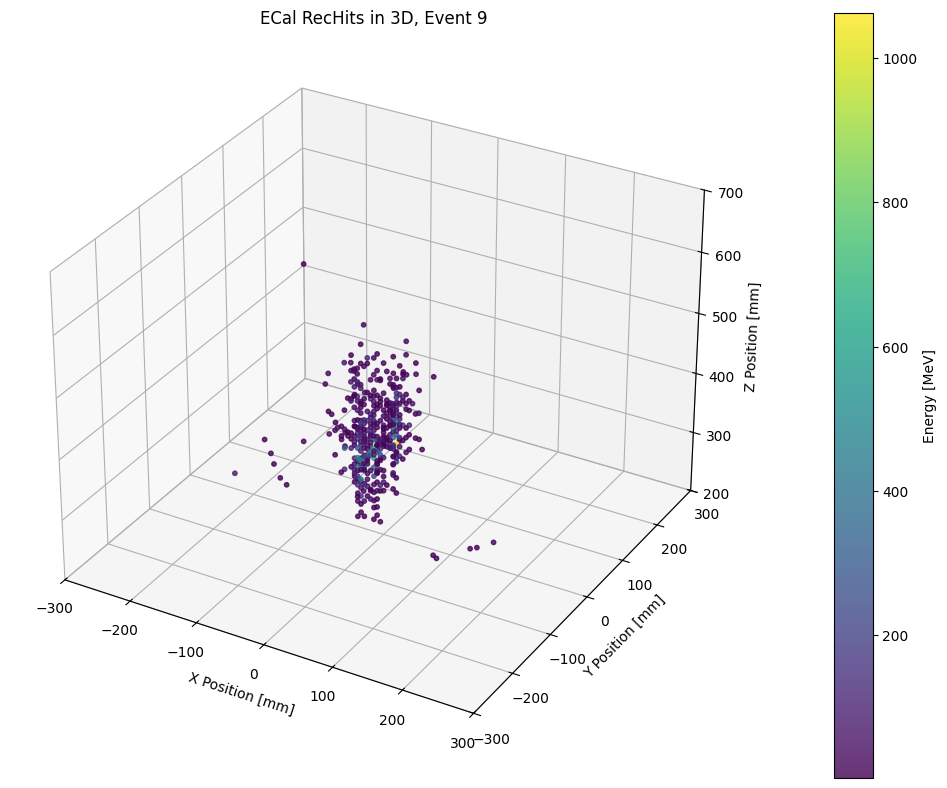

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import awkward as ak
import matplotlib.pyplot as plt

# convert one event to regular numpy arrays
x = ak.to_numpy(ecal_x[event_idx])
y = ak.to_numpy(ecal_y[event_idx])
z = ak.to_numpy(ecal_z[event_idx])
e = ak.to_numpy(ecal_energy[event_idx])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(x, y, z, c=e, s=10, alpha=0.8)

ax.set_title(f"ECal {ecal_hit_label} in 3D, Event {event_idx}")
ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")

ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)
ax.set_zlim(200, 700)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Energy [MeV]")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_hits_3d_event0.png", dpi=300)
plt.show()

### Interactive 3D

In [16]:
import plotly.graph_objects as go

event_idx = 8
#event_idx_with_noise

x = ak.to_numpy(ecal_x[event_idx])
y = ak.to_numpy(ecal_y[event_idx])
z = ak.to_numpy(ecal_z[event_idx])
e = ak.to_numpy(ecal_energy[event_idx])

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers",
            marker=dict(
                size=3,
                color=e,
                colorscale="Viridis",
                colorbar=dict(title="Energy [MeV]"),
                opacity=0.8,
            ),
        )
    ]
)

fig.update_layout(
    title=f"ECal {ecal_hit_label} 3D (Event {event_idx})",
    scene=dict(
        xaxis_title="X [mm]",
        yaxis_title="Y [mm]",
        zaxis_title="Z [mm]",
        xaxis=dict(range=[-300, 300]),
        yaxis=dict(range=[-300, 300]),
        zaxis=dict(range=[200, 700]),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

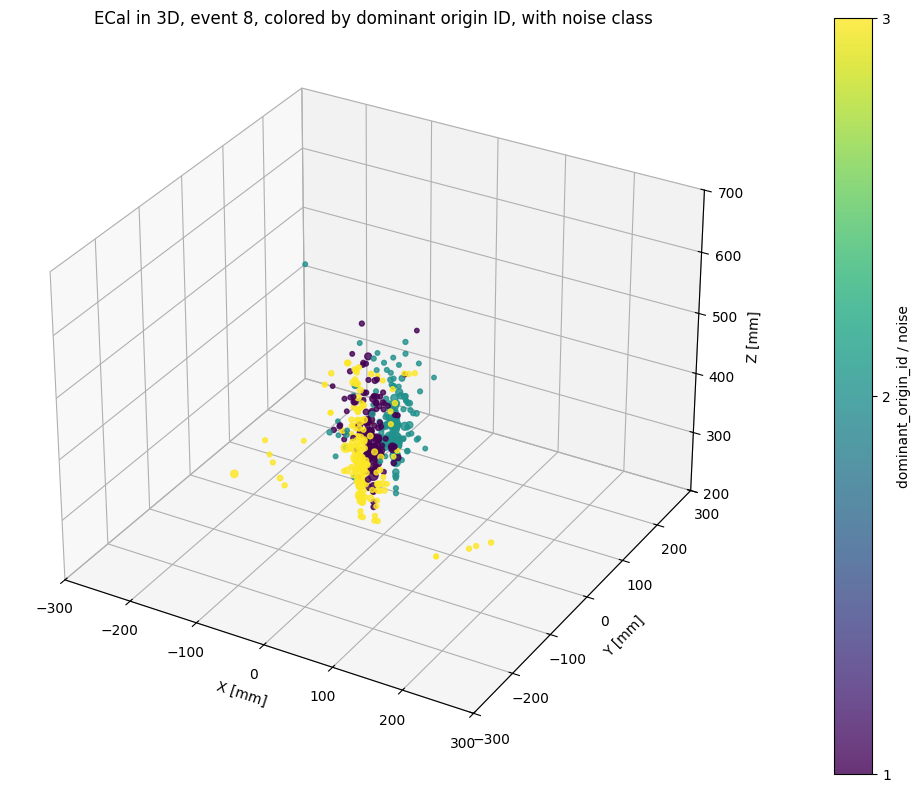

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

event_plot_df = hits_df.copy()

x = event_plot_df["x"].to_numpy()
y = event_plot_df["y"].to_numpy()
z = event_plot_df["z"].to_numpy()
e = event_plot_df["hit_edep"].to_numpy()
is_noise = event_plot_df.get("is_noise", False)
if not isinstance(is_noise, pd.Series):
    is_noise = pd.Series(False, index=event_plot_df.index)

event_plot_df["dominant_origin_or_noise"] = event_plot_df["dominant_origin"].astype(str).mask(
    is_noise.fillna(False).astype(bool),
    "noise",
)
origin = event_plot_df["dominant_origin_or_noise"]

codes, cats = make_category_codes(origin)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    x, y, z,
    c=codes,
    s=10 + 120 * e / e.max(),
    alpha=0.8,
)

ax.set_title(f"ECal in 3D, event {event_idx}, colored by dominant origin ID, with noise class")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_zlabel("Z [mm]")

ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)
ax.set_zlim(200, 700)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
tick_locs = np.arange(len(cats))
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(cats)
cbar.set_label("dominant_origin_id / noise")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_3d_origin_id_event0.png", dpi=300)
plt.show()

Event 8: 0 noise ECal RecHits


,hit_id,hit_energy,x,y,z,is_noise


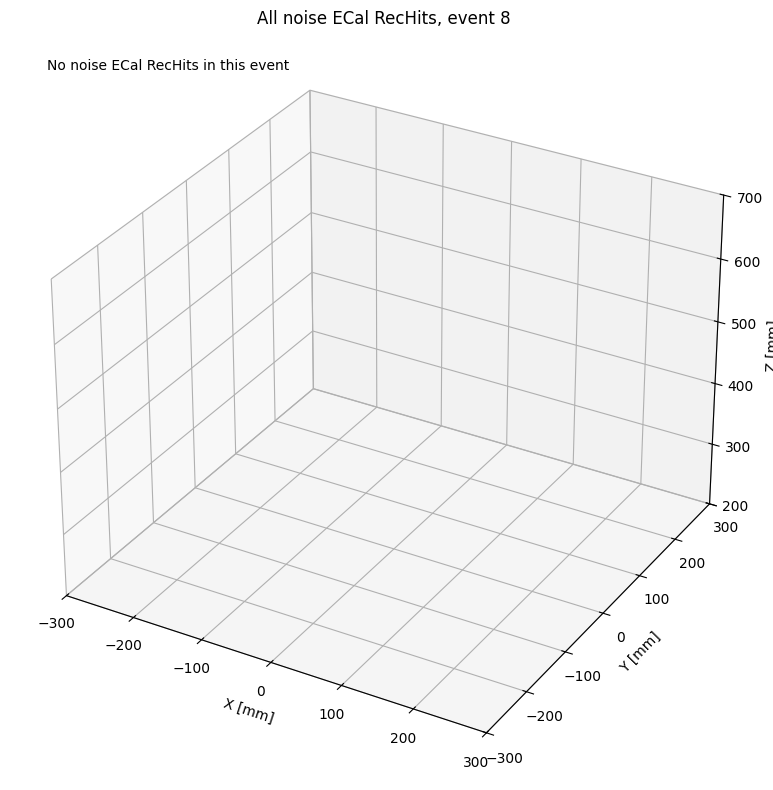

In [18]:
# Display all ECal RecHits marked as noise, independent of dominant contribution.
import awkward as ak
import matplotlib.pyplot as plt
import pandas as pd

noise_branches = [
    "EcalRecHits_overlay/EcalRecHits_overlay.id_",
    "EcalRecHits_overlay/EcalRecHits_overlay.energy_",
    "EcalRecHits_overlay/EcalRecHits_overlay.xpos_",
    "EcalRecHits_overlay/EcalRecHits_overlay.ypos_",
    "EcalRecHits_overlay/EcalRecHits_overlay.zpos_",
    "EcalRecHits_overlay/EcalRecHits_overlay.is_noise_",
]

if not overlay_tree or not all(branch in tree_keys for branch in noise_branches):
    print("No EcalRecHits_overlay noise flag is available for this file.")
    all_noise_hits_df = pd.DataFrame()
else:
    noise_arrs = tree.arrays(noise_branches)
    noise_mask = ak.to_numpy(noise_arrs["EcalRecHits_overlay/EcalRecHits_overlay.is_noise_"][event_idx]).astype(bool)

    all_rec_hits_df = pd.DataFrame({
        "hit_id": ak.to_numpy(noise_arrs["EcalRecHits_overlay/EcalRecHits_overlay.id_"][event_idx]),
        "hit_energy": ak.to_numpy(noise_arrs["EcalRecHits_overlay/EcalRecHits_overlay.energy_"][event_idx]),
        "x": ak.to_numpy(noise_arrs["EcalRecHits_overlay/EcalRecHits_overlay.xpos_"][event_idx]),
        "y": ak.to_numpy(noise_arrs["EcalRecHits_overlay/EcalRecHits_overlay.ypos_"][event_idx]),
        "z": ak.to_numpy(noise_arrs["EcalRecHits_overlay/EcalRecHits_overlay.zpos_"][event_idx]),
        "is_noise": noise_mask,
    })
    all_noise_hits_df = all_rec_hits_df[all_rec_hits_df["is_noise"]].copy()

    print(f"Event {event_idx}: {len(all_noise_hits_df)} noise ECal RecHits")
    display(all_noise_hits_df)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    if all_noise_hits_df.empty:
        ax.text2D(0.05, 0.95, "No noise ECal RecHits in this event", transform=ax.transAxes)
    else:
        sizes = 20 + 120 * all_noise_hits_df["hit_energy"] / all_noise_hits_df["hit_energy"].max()
        ax.scatter(
            all_noise_hits_df["x"],
            all_noise_hits_df["y"],
            all_noise_hits_df["z"],
            c="tab:red",
            s=sizes,
            alpha=0.9,
            label="noise",
        )
        ax.legend()

    ax.set_title(f"All noise ECal RecHits, event {event_idx}")
    ax.set_xlabel("X [mm]")
    ax.set_ylabel("Y [mm]")
    ax.set_zlabel("Z [mm]")
    ax.set_xlim(-300, 300)
    ax.set_ylim(-300, 300)
    ax.set_zlim(200, 700)
    plt.tight_layout()
    plt.show()

In [19]:
# Debug the ECal RecHit noise flag across events.
import awkward as ak
import pandas as pd

noise_flag_branch = "EcalRecHits_overlay/EcalRecHits_overlay.is_noise_"
noise_id_branch = "EcalRecHits_overlay/EcalRecHits_overlay.id_"
noise_energy_branch = "EcalRecHits_overlay/EcalRecHits_overlay.energy_"

if not overlay_tree or not all(branch in tree_keys for branch in [noise_flag_branch, noise_id_branch, noise_energy_branch]):
    print("No EcalRecHits_overlay noise flag is available for this file.")
else:
    debug_arrs = tree.arrays([noise_flag_branch, noise_id_branch, noise_energy_branch])
    noise_debug_rows = []

    for iev in range(len(debug_arrs[noise_flag_branch])):
        flags = ak.to_list(debug_arrs[noise_flag_branch][iev])
        ids_for_event = ak.to_list(debug_arrs[noise_id_branch][iev])
        energies_for_event = ak.to_list(debug_arrs[noise_energy_branch][iev])
        noisy = [(int(hit_id), float(energy)) for hit_id, energy, flag in zip(ids_for_event, energies_for_event, flags) if bool(flag)]
        noise_debug_rows.append({
            "event_idx": iev,
            "n_rec_hits": len(flags),
            "n_noise_hits": len(noisy),
            "noise_hit_ids": [hit_id for hit_id, _ in noisy],
            "noise_hit_energies": [energy for _, energy in noisy],
        })

    noise_debug_df = pd.DataFrame(noise_debug_rows)
    display(noise_debug_df)

    selected = noise_debug_df.loc[noise_debug_df["event_idx"] == event_idx].iloc[0]
    print(
        f"Selected event {event_idx}: {selected['n_noise_hits']} noise hits "
        f"out of {selected['n_rec_hits']} ECal RecHits"
    )

,event_idx,n_rec_hits,n_noise_hits,noise_hit_ids,noise_hit_energies
0,0,335,0,[],[]
1,1,350,0,[],[]
2,2,362,0,[],[]
3,3,321,1,[337654063],[3.239717483520508]
4,4,354,0,[],[]
...,...,...,...,...,...
4995,4995,349,0,[],[]
4996,4996,369,0,[],[]
4997,4997,318,0,[],[]
4998,4998,355,0,[],[]


Selected event 8: 0 noise hits out of 361 ECal RecHits


In [20]:
import pandas as pd
import plotly.express as px

event_plot_df = hits_df.copy()

def decode_dominant_track_id(encoded_id):
    if pd.isna(encoded_id) or int(encoded_id) < 0:
        return {
            "dominant_track_id_encoded": int(encoded_id) if not pd.isna(encoded_id) else pd.NA,
            "dominant_track_id_version": pd.NA,
            "dominant_track_id_event_index": pd.NA,
            "dominant_track_id_decoded": pd.NA,
        }

    decoded = decode_track_id(int(encoded_id))
    return {
        "dominant_track_id_encoded": decoded["raw"],
        "dominant_track_id_version": decoded["version"],
        "dominant_track_id_event_index": decoded["event_index"],
        "dominant_track_id_decoded": decoded["track_id"],
    }

decoded_track_ids = event_plot_df["dominant_track_id"].apply(decode_dominant_track_id).apply(pd.Series)
event_plot_df = event_plot_df.join(decoded_track_ids)

event_plot_df["track_str"] = event_plot_df["dominant_track_id"].astype(str)
event_plot_df["origin_str"] = event_plot_df["dominant_origin"].astype(str)
event_plot_df["pdg_str"] = event_plot_df["dominant_pdg"].astype(str)

fig = px.scatter_3d(
    event_plot_df,
    x="x",
    y="y",
    z="z",
    color="track_str",   # change to "origin_str" if you want
    size="hit_edep",
    hover_data={
        "hit_idx": True,
        "hit_id": True,
        "hit_edep": ':.3f',
        "dominant_track_id": False,
        "dominant_track_id_encoded": True,
        "dominant_track_id_decoded": True,
        "dominant_track_id_version": True,
        "dominant_track_id_event_index": True,
        "dominant_origin": True,
        "dominant_pdg": True,
        "dominant_frac": ':.3f',
        "n_contribs": True,
        "is_mixed": True,
        "all_track_ids": True,
        "all_origins": True,
        "x": ':.2f',
        "y": ':.2f',
        "z": ':.2f',
    },
    labels={
        "track_str": "dominant track ID encoded",
        "dominant_track_id_encoded": "dominant track ID encoded",
        "dominant_track_id_decoded": "dominant track ID decoded track_id",
        "dominant_track_id_version": "dominant track ID decoded version",
        "dominant_track_id_event_index": "dominant track ID decoded event_index",
    },
    title=f"ECal 3D, event {event_idx}, colored by dominant track ID",
)

fig.update_layout(
    scene=dict(
        xaxis_title="X [mm]",
        yaxis_title="Y [mm]",
        zaxis_title="Z [mm]",
        xaxis=dict(range=[-300, 300]),
        yaxis=dict(range=[-300, 300]),
        zaxis=dict(range=[200, 700]),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()